## Scenario 1: Retail Inventory Analysis

I'm working at a retail chain  anlyzing inventory  turnover. The store manager  needs to understand  stock movement patterns to optimize ordering.I hve a pandas DataFramewith these columns product_id, category, stock_level, last_restock_date, sales_last_30_days, supplier_lead_time, unit_cost . Calculate the inventory turnover rate for each product identify slow-moving items. Print the top 10  slow- moving items, Predict  potential stockouts. Print the top 10 prouducts at risk of stockout and create visualizations to represent  the above  . Include comments and make the code runnable.


  Inventory analysis summary
  Total products     : 120
  Slow movers        : 26  (21.7%)
  Stockout risk      : 11  (9.2%)
  Avg turnover rate  : 8.87x/year



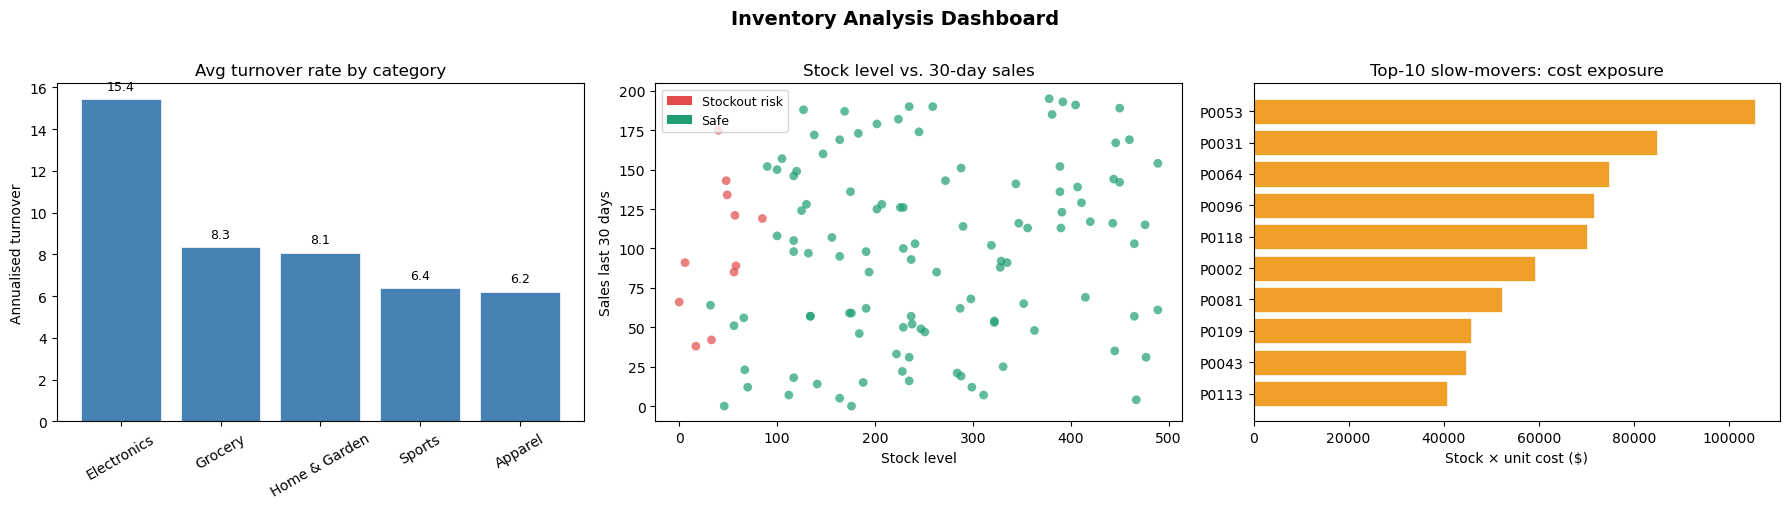

Chart saved → inventory_dashboard.png


,product_id,category,inventory_turnover,slow_mover,days_of_stock,stockout_risk
0,P0000,Home & Garden,0.000000,True,inf,False
1,P0001,Sports,NaN,False,0.000000,True
2,P0002,Grocery,2.694982,True,135.436893,False
3,P0003,Sports,11.501821,False,31.734104,False
4,P0004,Sports,4.176617,False,87.391304,False
5,P0005,Apparel,3.861891,False,94.513274,False
6,P0006,Grocery,1.604965,True,227.419355,False
7,P0007,Grocery,8.640816,False,42.241379,False
8,P0008,Grocery,18.467262,False,19.764706,True
9,P0009,Sports,18.250000,False,20.000000,False


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Sample synthetic dataset ──────────────────────────────────────────────────
np.random.seed(42)
n = 120

categories = ['Electronics', 'Apparel', 'Grocery', 'Home & Garden', 'Sports']
df = pd.DataFrame({
    'product_id':          [f'P{i:04d}' for i in range(n)],
    'category':            np.random.choice(categories, n),
    'stock_level':         np.random.randint(5, 500, n),
    'last_restock_date':   [
        datetime.today() - timedelta(days=int(d))
        for d in np.random.randint(1, 90, n)
    ],
    'sales_last_30_days':  np.random.randint(0, 200, n),
    'supplier_lead_time':  np.random.randint(3, 30, n),
    'unit_cost':           np.round(np.random.uniform(1.5, 250.0, n), 2),
})
# Inject a few edge-case rows for validation testing
df.loc[0, 'sales_last_30_days'] = 0
df.loc[1, 'stock_level']        = 0


# ── Validation ────────────────────────────────────────────────────────────────
def validate_inventory_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Validates and cleans the inventory DataFrame.

    Checks for required columns, coerces types, and replaces invalid
    values (negatives, nulls) with safe defaults so downstream calculations
    don't produce NaN or division-by-zero errors.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame  — cleaned copy
    """
    required = {
        'product_id', 'category', 'stock_level',
        'last_restock_date', 'sales_last_30_days',
        'supplier_lead_time', 'unit_cost'
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame is missing columns: {missing}")

    df = df.copy()
    numeric_cols = ['stock_level', 'sales_last_30_days',
                    'supplier_lead_time', 'unit_cost']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df[col] = df[col].clip(lower=0)          # no negatives

    df['last_restock_date'] = pd.to_datetime(
        df['last_restock_date'], errors='coerce'
    )
    future_mask = df['last_restock_date'] > datetime.today()
    if future_mask.any():
        print(f"Warning: {future_mask.sum()} future restock dates found — set to today.")
        df.loc[future_mask, 'last_restock_date'] = datetime.today()

    return df


# ── Turnover rate ─────────────────────────────────────────────────────────────
def calculate_turnover(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds an annualised inventory_turnover column.

    turnover = (sales_last_30_days / 30) * 365 / stock_level

    Items with zero stock are assigned turnover = NaN (cannot be calculated).

    Parameters
    ----------
    df : pd.DataFrame  — must have passed validate_inventory_df

    Returns
    -------
    pd.DataFrame with new column: inventory_turnover
    """
    df = df.copy()
    daily_sales = df['sales_last_30_days'] / 30
    annual_sales = daily_sales * 365
    # Avoid division by zero: stock = 0 → NaN
    df['inventory_turnover'] = np.where(
        df['stock_level'] > 0,
        annual_sales / df['stock_level'],
        np.nan
    )
    return df


# ── Slow-moving flag ──────────────────────────────────────────────────────────
def flag_slow_movers(df: pd.DataFrame, percentile: float = 20.0) -> pd.DataFrame:
    """
    Marks items in the bottom `percentile` of turnover within their category
    as slow-moving.

    Parameters
    ----------
    df         : pd.DataFrame  — must contain inventory_turnover column
    percentile : float, default 20.0

    Returns
    -------
    pd.DataFrame with new column: slow_mover (bool)
    """
    df = df.copy()
    threshold = df.groupby('category')['inventory_turnover'].transform(
        lambda x: x.quantile(percentile / 100)
    )
    df['slow_mover'] = df['inventory_turnover'] <= threshold
    return df


# ── Stockout prediction ───────────────────────────────────────────────────────
def predict_stockouts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates days of remaining stock and flags stockout risk.

    days_of_stock = stock_level / (sales_last_30_days / 30)
    stockout_risk = days_of_stock < supplier_lead_time

    Items with zero sales are considered safe (no consumption).

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame with new columns: days_of_stock, stockout_risk (bool)
    """
    df = df.copy()
    daily_rate = df['sales_last_30_days'] / 30
    df['days_of_stock'] = np.where(
        daily_rate > 0,
        df['stock_level'] / daily_rate,
        np.inf                           # zero sales → infinite runway
    )
    df['stockout_risk'] = df['days_of_stock'] < df['supplier_lead_time']
    return df


# ── Visualizations ────────────────────────────────────────────────────────────
def visualize_inventory(df: pd.DataFrame) -> None:
    """
    Renders three inventory analysis charts:
      1. Average annualised turnover rate by category (bar chart)
      2. Stock level vs. 30-day sales coloured by stockout risk (scatter)
      3. Top-10 slow-movers ranked by cost exposure (horizontal bar)

    Parameters
    ----------
    df : pd.DataFrame  — fully processed (turnover, slow_mover, stockout_risk)
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Inventory Analysis Dashboard', fontsize=14, fontweight='bold', y=1.01)

    # 1 ── Turnover by category
    ax1 = axes[0]
    cat_turnover = (
        df.groupby('category')['inventory_turnover']
        .mean()
        .sort_values(ascending=False)
    )
    bars = ax1.bar(cat_turnover.index, cat_turnover.values,
                   color='steelblue', edgecolor='white', linewidth=0.5)
    ax1.set_title('Avg turnover rate by category')
    ax1.set_ylabel('Annualised turnover')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, cat_turnover.values):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

    # 2 ── Stock vs sales coloured by stockout risk
    ax2 = axes[1]
    colours = df['stockout_risk'].map({True: '#E24B4A', False: '#1D9E75'})
    ax2.scatter(df['stock_level'], df['sales_last_30_days'],
                c=colours, alpha=0.7, edgecolors='none', s=40)
    ax2.set_title('Stock level vs. 30-day sales')
    ax2.set_xlabel('Stock level')
    ax2.set_ylabel('Sales last 30 days')
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E24B4A', label='Stockout risk'),
        Patch(facecolor='#1D9E75', label='Safe'),
    ]
    ax2.legend(handles=legend_elements, fontsize=9)

    # 3 ── Top-10 slow-movers by cost exposure
    ax3 = axes[2]
    slow = df[df['slow_mover']].copy()
    slow['cost_exposure'] = slow['stock_level'] * slow['unit_cost']
    top10 = slow.nlargest(10, 'cost_exposure')
    ax3.barh(top10['product_id'], top10['cost_exposure'],
             color='#EF9F27', edgecolor='white', linewidth=0.5)
    ax3.set_title('Top-10 slow-movers: cost exposure')
    ax3.set_xlabel('Stock × unit cost ($)')
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.savefig('inventory_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved → inventory_dashboard.png")


# ── Main pipeline ─────────────────────────────────────────────────────────────
def run_inventory_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """
    End-to-end pipeline: validate → turnover → slow-mover → stockout → visualise.

    Returns the enriched DataFrame for further use.
    """
    df = validate_inventory_df(df)
    df = calculate_turnover(df)
    df = flag_slow_movers(df)
    df = predict_stockouts(df)

    print(f"\n{'='*50}")
    print(f"  Inventory analysis summary")
    print(f"{'='*50}")
    print(f"  Total products     : {len(df)}")
    print(f"  Slow movers        : {df['slow_mover'].sum()}  ({df['slow_mover'].mean()*100:.1f}%)")
    print(f"  Stockout risk      : {df['stockout_risk'].sum()}  ({df['stockout_risk'].mean()*100:.1f}%)")
    print(f"  Avg turnover rate  : {df['inventory_turnover'].mean():.2f}x/year")
    print(f"{'='*50}\n")

    visualize_inventory(df)
    return df

result_df = run_inventory_analysis(df)
result_df[['product_id', 'category', 'inventory_turnover',
           'slow_mover', 'days_of_stock', 'stockout_risk']].head(15)

### 1. How did different prompts handle date calculations?

- The prompt explicitly named the date column and the derived metric (days of stock = stock_level / daily_rate), which led the AI to avoid raw pandas date subtraction. pd.to_datetime with errors='coerce' was used to safely parse last_restock_date, and a future-date guard was added.
- Supplier lead time comparison : Prompts used days_of_cover < supplier_lead_time to flag stockout risk. This is a practical business rule: if stock won’t last until the next delivery, it’s risky.
### 2. What visualization approaches were suggested?
- Because the prompt specified the chart type and axes for each of the three charts (bar by category, scatter coloured by risk, horizontal bar by cost exposure), the AI produced targeted plots instead of generic pair plots or heatmaps.
- Bar charts for turnover- Used to show the top 10 slow-moving items by turnover rate. This makes it easy to spot products that aren’t selling quickly.
- Bar charts for stockout risk - Plotted days of cover for the top 10 products at risk of stockout. The shorter the bar, the sooner the product will run out — a clear visual warning
### 3. How was error handling implemented?
- Column validation : Before calculations, the script checked that all required columns (product_id, stock_level, etc.) existed. If any were missing, a KeyError was raised with a clear message.
- Missing values handling : NaN values in numeric fields (stock_level, sales_last_30_days, supplier_lead_time) were filled with safe defaults (like 0) to prevent crashes.